# Heston UKF+NUTS — MLE Warm-Start

A NUTS chain that starts far from the posterior mode spends most of warmup
climbing the likelihood surface rather than exploring it. This notebook
demonstrates an MLE warm-start workflow:

1. **Moment estimators** — closed-form initial guess from realized variance statistics
2. **L-BFGS-B on the UKF log-likelihood** — seconds of scipy optimisation to find a near-mode starting point
3. **NUTS with `init_to_value`** — chains start at the MLE and hit the posterior immediately
4. **Comparison** — warm-start vs arbitrary cold-start diagnostics

We use the A2 setup from `heston-ukf-nuts.ipynb` (daily return + realized
variance) because that posterior is well-identified and MLE converges cleanly.
The 2D UKF log-likelihood is the MLE objective — no FFT pricing or options data
required; it is purely historical calibration.

### Why MLE in unconstrained space?

NUTS works in the unconstrained reparametrisation:
$$\psi = (\log\kappa,\; \log\theta,\; \log\sigma,\; \text{arctanh}(\rho),\; \log v_0)$$

The MLE is also run in this space so the optimised $\hat{\psi}$ can be passed
directly to `init_to_value` without any conversion. The Jacobian of the
reparametrisation does **not** appear in the MLE objective — it only matters
for the Bayesian posterior. For initialisation purposes this distinction is
irrelevant: we just want the chains to start near the mode.

In [1]:
import os

# Force JAX to use CPU — Metal GPU doesn't support the popcnt operation
# that NUTS uses internally for its binary tree traversal.
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
import arviz as az
import scipy.optimize as opt

import jax
# Enable 64-bit precision — must be called before any JAX operations.
# Float32 accumulates ~40 nats of error in the 2D UKF over 252 steps.
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

np.random.seed(42)
print(f"JAX {jax.__version__}  |  NumPyro {numpyro.__version__}")
print(f"Devices: {jax.devices()}")
print(f"JAX default dtype: {jnp.zeros(1).dtype}  (should be float64)")

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


JAX 0.4.35  |  NumPyro 0.19.0
Metal device set to: Apple M3 Pro

systemMemory: 36.00 GB
maxCacheSize: 14.04 GB

Devices: [CpuDevice(id=0)]
JAX default dtype: float64  (should be float64)


W0000 00:00:1776458246.475284 29546591 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776458246.486135 29546591 service.cc:145] XLA service 0x145b9c6f0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776458246.486143 29546591 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776458246.487327 29546591 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776458246.487340 29546591 mps_client.cc:384] XLA backend will use up to 30150197248 bytes on device 0 for SimpleAllocator.


In [2]:
# ── True parameters and synthetic data ────────────────────────────────────────
# Identical to heston-ukf-nuts.ipynb for comparability.

TRUE = {
    "kappa": 3.0,
    "theta": 0.04,
    "sigma": 0.4,
    "rho":  -0.7,
    "v0":   0.04,
}
MU = 0.05
S0 = 100.0
T  = 252
dt = 1 / 252
H_PER_DAY = 8
PARAM_NAMES = ["kappa", "theta", "sigma", "rho", "v0"]
true_vals   = [TRUE[p] for p in PARAM_NAMES]
labels      = [r"$\kappa$", r"$\theta$", r"$\sigma$", r"$\rho$", r"$v_0$"]


def simulate_heston(kappa, theta, sigma, rho, v0, mu=MU, S0=S0, T=T, dt=dt, seed=None):
    """Euler-Maruyama Heston simulation. v_t is annualised variance."""
    rng = np.random.default_rng(seed)
    v, S = np.zeros(T + 1), np.zeros(T + 1)
    v[0], S[0] = v0, S0
    z1, z2 = rng.standard_normal(T), rng.standard_normal(T)
    dWs = np.sqrt(dt) * z1
    dWv = np.sqrt(dt) * (rho * z1 + np.sqrt(1 - rho**2) * z2)
    for t in range(T):
        sv      = np.sqrt(max(v[t], 0.0))
        v[t+1]  = max(v[t] + kappa*(theta - v[t])*dt + sigma*sv*dWv[t], 0.0)
        S[t+1]  = S[t] * np.exp((mu - 0.5*v[t])*dt + sv*dWs[t])
    return S, v, np.log(S[1:] / S[:-1])


# ── Simulate hourly, aggregate to daily return + RV ───────────────────────────
T_HOURLY  = T * H_PER_DAY
dt_hourly = 1.0 / (252 * H_PER_DAY)

S_hourly, v_hourly, r_hourly = simulate_heston(**TRUE, T=T_HOURLY, dt=dt_hourly, seed=0)

r_daily = r_hourly.reshape(T, H_PER_DAY).sum(axis=1)
RV_daily = (r_hourly ** 2).reshape(T, H_PER_DAY).sum(axis=1)
v_eod    = v_hourly[H_PER_DAY::H_PER_DAY]

rdaily_jax = jnp.array(r_daily)   # float64
rv_jax     = jnp.array(RV_daily)  # float64

rv_corr = np.corrcoef(RV_daily / dt, v_eod)[0, 1]
print(f"Daily observations:  {T} returns + {T} RV values")
print(f"RV vs true v_t corr: {rv_corr:.3f}   (1.0 = perfect proxy)")
print(f"Mean RV/dt:          {(RV_daily/dt).mean():.4f}   True θ: {TRUE['theta']:.4f}")

Daily observations:  252 returns + 252 RV values
RV vs true v_t corr: 0.752   (1.0 = perfect proxy)
Mean RV/dt:          0.0416   True θ: 0.0400


In [3]:
# ── 2D UKF in NumPy — used as the MLE objective ────────────────────────────────
# State: v_t (scalar).  Observations: [r_t, RV_t] (2D).
# Copied from heston-ukf-nuts.ipynb cell 10dd01de; see that notebook for derivation.

def ukf_rv_numpy(daily_returns, daily_rv, kappa, theta, sigma, rho, v0,
                 mu=MU, dt=1/252, n_intraday=8):
    """2D UKF for Heston. Returns (filtered means, total log-lik)."""
    W0, Wi = 2.0/3.0, 1.0/6.0
    m, P   = float(v0), float(theta * 0.5)
    ms, lls = np.zeros(len(daily_returns)), np.zeros(len(daily_returns))

    for t, (r_t, rv_t) in enumerate(zip(daily_returns, daily_rv)):
        v_s = max(m, 1e-6)

        sp  = np.sqrt(3.0 * P)
        f   = np.array([m, m+sp, m-sp]) + kappa*(theta - np.array([m, m+sp, m-sp]))*dt
        m_p = W0*f[0] + Wi*(f[1] + f[2])
        P_p = max(W0*(f[0]-m_p)**2 + Wi*((f[1]-m_p)**2+(f[2]-m_p)**2)
                  + sigma**2*v_s*dt, 1e-8)
        v_p = max(m_p, 1e-6)

        yr_p  = (mu - 0.5*m_p)*dt
        yrv_p = m_p * dt

        S_rr   = max(0.25*P_p*dt**2 + v_p*dt,                  1e-10)
        S_rvrv = max(P_p*dt**2 + 2.0*v_p**2*dt**2/n_intraday, 1e-10)
        S_r_rv = -0.5*P_p*dt**2

        Pvy_r  = -0.5*P_p*dt + rho*sigma*v_p*dt
        Pvy_rv = P_p*dt

        det  = max(S_rr*S_rvrv - S_r_rv**2, 1e-14)
        K_r  = (Pvy_r*S_rvrv  - Pvy_rv*S_r_rv) / det
        K_rv = (Pvy_rv*S_rr   - Pvy_r*S_r_rv ) / det

        innov_r, innov_rv = r_t - yr_p, rv_t - yrv_p
        m = max(m_p + K_r*innov_r + K_rv*innov_rv, 1e-6)
        P = max(P_p - K_r*Pvy_r   - K_rv*Pvy_rv,  1e-8)

        si_r  = (S_rvrv*innov_r  - S_r_rv*innov_rv) / det
        si_rv = (S_rr  *innov_rv - S_r_rv*innov_r ) / det
        lls[t] = -0.5*(2.0*np.log(2*np.pi) + np.log(det)
                       + innov_r*si_r + innov_rv*si_rv)
        ms[t]  = m

    return ms, np.sum(lls)


# Reference log-lik at true params
_, ll_true_2d = ukf_rv_numpy(r_daily, RV_daily, **TRUE)
print(f"2D UKF log-lik at true params: {ll_true_2d:.2f}")

2D UKF log-lik at true params: 2770.18


In [4]:
# ── 2D UKF in JAX — used by NUTS ──────────────────────────────────────────────
# Identical algorithm; jax.lax.scan replaces the for-loop.
#
# FLOOR NOTE: S_rvrv = P_p*dt² + 2*v²*dt²/H.
# With v≈0.04, dt=1/252, H=8: S_rvrv ≈ 8e-9.
# Using a 1e-8 floor would be *above* this typical value and would
# inflate the det (and lower log-lik) on almost every step.
# Use 1e-12 so the floor never fires in normal operation.

def ukf_rv_loglik_jax(daily_returns, daily_rv, kappa, theta, sigma, rho, v0,
                       mu=MU, dt=1/252, n_intraday=8):
    W0, Wi = 2.0/3.0, 1.0/6.0

    def step(carry, obs_t):
        m, P = carry
        r_t, rv_t = obs_t[0], obs_t[1]
        v_s = jnp.maximum(m, 1e-6)

        sp  = jnp.sqrt(3.0 * P)
        f0  = m        + kappa*(theta - m       )*dt
        f1  = (m + sp) + kappa*(theta - (m + sp))*dt
        f2  = (m - sp) + kappa*(theta - (m - sp))*dt
        m_p = W0*f0 + Wi*(f1 + f2)
        P_p = jnp.maximum(
            W0*(f0-m_p)**2 + Wi*((f1-m_p)**2 + (f2-m_p)**2) + sigma**2*v_s*dt,
            1e-8)
        v_p = jnp.maximum(m_p, 1e-6)

        yr_p  = (mu - 0.5*m_p)*dt
        yrv_p = m_p * dt

        # Use 1e-12 floors — typical S_rvrv ≈ 8e-9, so 1e-8 would be wrong here
        S_rr   = jnp.maximum(0.25*P_p*dt**2 + v_p*dt,                  1e-12)
        S_rvrv = jnp.maximum(P_p*dt**2 + 2.0*v_p**2*dt**2/n_intraday, 1e-12)
        S_r_rv = -0.5*P_p*dt**2

        Pvy_r  = -0.5*P_p*dt + rho*sigma*v_p*dt
        Pvy_rv = P_p*dt

        det    = jnp.maximum(S_rr*S_rvrv - S_r_rv**2, 1e-14)
        K_r    = (Pvy_r*S_rvrv  - Pvy_rv*S_r_rv) / det
        K_rv   = (Pvy_rv*S_rr   - Pvy_r*S_r_rv ) / det

        innov_r  = r_t  - yr_p
        innov_rv = rv_t - yrv_p
        m_new = jnp.maximum(m_p + K_r*innov_r + K_rv*innov_rv, 1e-6)
        P_new = jnp.maximum(P_p - K_r*Pvy_r   - K_rv*Pvy_rv,  1e-8)

        si_r  = (S_rvrv*innov_r  - S_r_rv*innov_rv) / det
        si_rv = (S_rr  *innov_rv - S_r_rv*innov_r ) / det
        ll    = -0.5*(2.0*jnp.log(2.0*jnp.pi) + jnp.log(det)
                     + innov_r*si_r + innov_rv*si_rv)

        return (m_new, P_new), ll

    obs_arr = jnp.stack([daily_returns, daily_rv], axis=1)
    init    = (jnp.maximum(v0, 1e-6), jnp.maximum(theta*0.5, 1e-8))
    _, lls  = jax.lax.scan(step, init, obs_arr)
    return jnp.sum(lls)


# Sanity check — gap should be < 0.1 nats with float64 and matching floors
ll_jax = float(ukf_rv_loglik_jax(
    rdaily_jax, rv_jax, **{k: float(v) for k, v in TRUE.items()}))
print(f"JAX  2D UKF log-lik: {ll_jax:.4f}")
print(f"NumPy 2D UKF log-lik: {ll_true_2d:.4f}  (gap: {abs(ll_jax - ll_true_2d):.4f} nats)")

JAX  2D UKF log-lik: 2770.1752
NumPy 2D UKF log-lik: 2770.1752  (gap: 0.0000 nats)


## Step 1 — Moment Estimators

Before any optimisation we can extract a rough but principled initial guess
directly from the data statistics. These estimates are instantaneous — no
iterative fitting required.

| Parameter | Estimator | Intuition |
|---|---|---|
| $\theta$ | $\overline{\mathrm{RV}}/\Delta t$ | Long-run mean of RV ≈ long-run variance |
| $v_0$ | $\mathrm{RV}_{1:\mathrm{early}}/\Delta t$ | Early-sample average avoids late-regime contamination |
| $\kappa$ | $-\log(\hat{\phi})/\Delta t$ from AR(1) of $\mathrm{RV}_t$ | AR coefficient of variance proxy gives mean-reversion speed |
| $\sigma$ | $\sqrt{\mathrm{Var}(\Delta\mathrm{RV}_t) / (\theta\cdot\Delta t)}$ | $\mathrm{Var}(\Delta v_t) \approx \sigma^2 \theta \Delta t$ |
| $\rho$ | $\mathrm{Corr}(r_t,\; \mathrm{RV}_t - \mathrm{RV}_{t-1})$ | Leverage: down-days coincide with rising variance |

These are not MLE estimates — they are moment conditions that happen to be
consistent. The quality is enough to put L-BFGS-B in the right basin.

In [5]:
# ── Moment estimators for Heston parameters ───────────────────────────────────

# θ — long-run variance from mean RV
theta_mom = float(np.mean(RV_daily) / dt)

# v0 — initial variance from first ~20 days of RV
v0_mom = float(np.mean(RV_daily[:20]) / dt)

# κ — from AR(1) of RV series: RV_t ≈ φ*RV_{t-1} + ε  →  κ = -log(φ)/dt
# LIMITATION: daily RV has high measurement noise (only H=8 bars), which
# severely dilutes the lag-1 autocorrelation. With 252 daily obs the sample
# correlation can be near 0 or even negative, giving κ >> 100.
# Cap at 30 — if the raw estimate is that extreme it's just noise; L-BFGS-B
# will move κ to a sensible value regardless of where it starts.
phi = np.corrcoef(RV_daily[:-1], RV_daily[1:])[0, 1]
phi = np.clip(phi, 0.01, 0.999)   # prevent log(0)
kappa_mom = float(np.clip(-np.log(phi) / dt, 0.1, 30.0))

# σ — vol-of-vol from variance of RV increments
# Var(ΔRV) ≈ σ²·θ·dt + measurement noise; formula understimates σ due to noise
dRV = np.diff(RV_daily)
sigma_mom = float(np.sqrt(np.var(dRV) / (theta_mom * dt**2)))
sigma_mom = float(np.clip(sigma_mom, 0.05, 5.0))

# ρ — leverage from correlation of returns with RV changes
# Also noisy with only 252 daily points; L-BFGS-B corrects this quickly
rho_mom = float(np.corrcoef(r_daily[1:], dRV)[0, 1])
rho_mom = float(np.clip(rho_mom, -0.99, 0.99))

moment_guess = {
    "kappa": kappa_mom,
    "theta": theta_mom,
    "sigma": sigma_mom,
    "rho":   rho_mom,
    "v0":    v0_mom,
}

print("Moment estimators vs true parameters:")
print(f"{'Param':<8} {'True':>8} {'Moment':>8} {'Ratio':>8}")
print("-" * 36)
for p in PARAM_NAMES:
    t = TRUE[p]; m = moment_guess[p]
    ratio = m / t if t != 0 else float('nan')
    print(f"{p:<8} {t:>8.4f} {m:>8.4f} {ratio:>8.2f}×")

_, ll_moment = ukf_rv_numpy(r_daily, RV_daily, **moment_guess)
print(f"\nUKF log-lik at moment guess: {ll_moment:.2f}")
print(f"UKF log-lik at true params:  {ll_true_2d:.2f}")
print(f"Gap:                         {ll_true_2d - ll_moment:.2f} nats")
print(f"\nNote: moment estimators are rough starting points, not accurate estimates.")
print(f"κ especially is unreliable from noisy daily RV — L-BFGS-B corrects this.")

Moment estimators vs true parameters:
Param        True   Moment    Ratio
------------------------------------
kappa      3.0000  30.0000    10.00×
theta      0.0400   0.0416     1.04×
sigma      0.4000   0.1452     0.36×
rho       -0.7000  -0.0096     0.01×
v0         0.0400   0.0356     0.89×

UKF log-lik at moment guess: 2644.17
UKF log-lik at true params:  2770.18
Gap:                         126.01 nats

Note: moment estimators are rough starting points, not accurate estimates.
κ especially is unreliable from noisy daily RV — L-BFGS-B corrects this.


## Step 2 — MLE and MAP via L-BFGS-B

We optimise two objectives with `scipy.optimize.minimize`:

- **MLE** — maximises only the UKF log-likelihood
- **MAP** — maximises log-likelihood + log-prior (same Normal priors as the NumPyro model)

Both are differentiated through the **same JAX UKF** that NUTS uses,
using `jax.value_and_grad` to supply exact analytical gradients
(`jac=True` in scipy). This ensures the optimisation and sampling targets
are numerically identical.

**Why MAP is better for warm-starting NUTS:**

The MLE slides along the banana ridge to wherever the likelihood alone peaks
— often far from the prior's centre of mass. MAP is regularised by the prior,
so its mode coincides with the posterior mode (the actual target of NUTS).
Starting NUTS at the MAP rather than the MLE means chains are already at the
posterior mode and warmup only needs to calibrate the step-size, not navigate
the surface.

$$\underbrace{\log p(\psi \mid y)}_{\text{MAP objective}} = \underbrace{\mathcal{L}(\psi; y)}_{\text{MLE objective}} + \underbrace{\log p(\psi)}_{\text{prior penalty}}$$

In [6]:
import time

# ── Unconstrained parameterisation helpers ────────────────────────────────────

def to_unconstrained(kappa, theta, sigma, rho, v0):
    return np.array([np.log(kappa), np.log(theta), np.log(sigma),
                     np.arctanh(rho), np.log(v0)])

def from_unconstrained(psi):
    return {"kappa": float(np.exp(psi[0])), "theta": float(np.exp(psi[1])),
            "sigma": float(np.exp(psi[2])), "rho":   float(np.tanh(psi[3])),
            "v0":    float(np.exp(psi[4]))}


# ── JAX UKF log-lik as a function of ψ — used for BOTH MLE and MAP ───────────
# Using the JAX UKF (not NumPy) ensures MLE/MAP and NUTS operate on the
# same numerical function. jax.value_and_grad gives exact analytical gradients.

def ukf_loglik_psi(psi):
    """Log-lik in unconstrained space — differentiable via jax.grad."""
    return ukf_rv_loglik_jax(
        rdaily_jax, rv_jax,
        kappa=jnp.exp(psi[0]), theta=jnp.exp(psi[1]), sigma=jnp.exp(psi[2]),
        rho=jnp.tanh(psi[3]),  v0=jnp.exp(psi[4]),
    )

_ll_val_grad  = jax.jit(jax.value_and_grad(ukf_loglik_psi))
psi0_jax      = jnp.array(to_unconstrained(**moment_guess))
_             = _ll_val_grad(psi0_jax)   # warm-up JIT compilation

def neg_mle(psi):
    val, grad = _ll_val_grad(jnp.array(psi))
    return -float(val), -np.array(grad)


# ── MLE ───────────────────────────────────────────────────────────────────────
print("MLE: L-BFGS-B on UKF log-lik (JAX gradients) ...")
t0 = time.perf_counter()
result_mle = opt.minimize(neg_mle, np.array(psi0_jax), method="L-BFGS-B", jac=True,
                           options={"maxiter": 2000, "ftol": 1e-12, "gtol": 1e-8})
elapsed_mle = time.perf_counter() - t0
mle_params  = from_unconstrained(result_mle.x)
_, ll_mle   = ukf_rv_numpy(r_daily, RV_daily, **mle_params)
print(f"  {elapsed_mle:.2f}s  |  {result_mle.nit} iters  |  success={result_mle.success}  |  loglik={ll_mle:.2f}")


# ── MAP — same objective + log-prior ─────────────────────────────────────────
# Priors exactly match the NumPyro model (same σ values):
#   log_κ  ~ N(0.5,  2.0),  log_θ ~ N(-3.2, 1.5),  log_σ ~ N(-0.5, 1.5)
#   ρ_raw  ~ N(0.0,  1.5),  log_v0~ N(-3.2, 1.5)

def map_logobj_psi(psi):
    ll = ukf_loglik_psi(psi)
    lp = (-0.5 * ((psi[0] - 0.5 ) / 2.0)**2   # log_kappa
        + -0.5 * ((psi[1] + 3.2 ) / 1.5)**2   # log_theta
        + -0.5 * ((psi[2] + 0.5 ) / 1.5)**2   # log_sigma
        + -0.5 * ((psi[3]       ) / 1.5)**2   # rho_raw
        + -0.5 * ((psi[4] + 3.2 ) / 1.5)**2)  # log_v0
    return ll + lp

_map_val_grad = jax.jit(jax.value_and_grad(map_logobj_psi))
_             = _map_val_grad(psi0_jax)   # warm up

def neg_map(psi):
    val, grad = _map_val_grad(jnp.array(psi))
    return -float(val), -np.array(grad)

print("\nMAP: L-BFGS-B on log-lik + log-prior (JAX gradients) ...")
t0 = time.perf_counter()
result_map = opt.minimize(neg_map, np.array(psi0_jax), method="L-BFGS-B", jac=True,
                           options={"maxiter": 2000, "ftol": 1e-12, "gtol": 1e-8})
elapsed_map = time.perf_counter() - t0
map_params  = from_unconstrained(result_map.x)
_, ll_map   = ukf_rv_numpy(r_daily, RV_daily, **map_params)
print(f"  {elapsed_map:.2f}s  |  {result_map.nit} iters  |  success={result_map.success}  |  loglik={ll_map:.2f}")


# ── Comparison table ──────────────────────────────────────────────────────────
print(f"\n{'Param':<8} {'True':>8} {'MLE':>8} {'MAP':>8}  {'Notes'}")
print("-" * 60)
for p in PARAM_NAMES:
    flag = ""
    if abs(mle_params[p] - map_params[p]) / max(abs(TRUE[p]), 0.01) > 0.1:
        flag = " ← prior moves this"
    print(f"{p:<8} {TRUE[p]:>8.4f} {mle_params[p]:>8.4f} {map_params[p]:>8.4f}{flag}")

print(f"\n{'':8} {'':>8} {ll_mle:>8.2f} {ll_map:>8.2f}   log-lik at solution")
print(f"{'':8} {'':>8} {mle_params['kappa']*mle_params['theta']:>8.4f} "
      f"{map_params['kappa']*map_params['theta']:>8.4f}   κ·θ  (true: {TRUE['kappa']*TRUE['theta']:.4f})")

MLE: L-BFGS-B on UKF log-lik (JAX gradients) ...
  0.06s  |  23 iters  |  success=True  |  loglik=2779.70

MAP: L-BFGS-B on log-lik + log-prior (JAX gradients) ...
  0.06s  |  22 iters  |  success=True  |  loglik=2779.67

Param        True      MLE      MAP  Notes
------------------------------------------------------------
kappa      3.0000   7.2789   6.2870 ← prior moves this
theta      0.0400   0.0250   0.0241
sigma      0.4000   0.5699   0.5612
rho       -0.7000  -0.6870  -0.6889
v0         0.0400   0.1239   0.1200

                   2779.70  2779.67   log-lik at solution
                    0.1817   0.1517   κ·θ  (true: 0.1200)


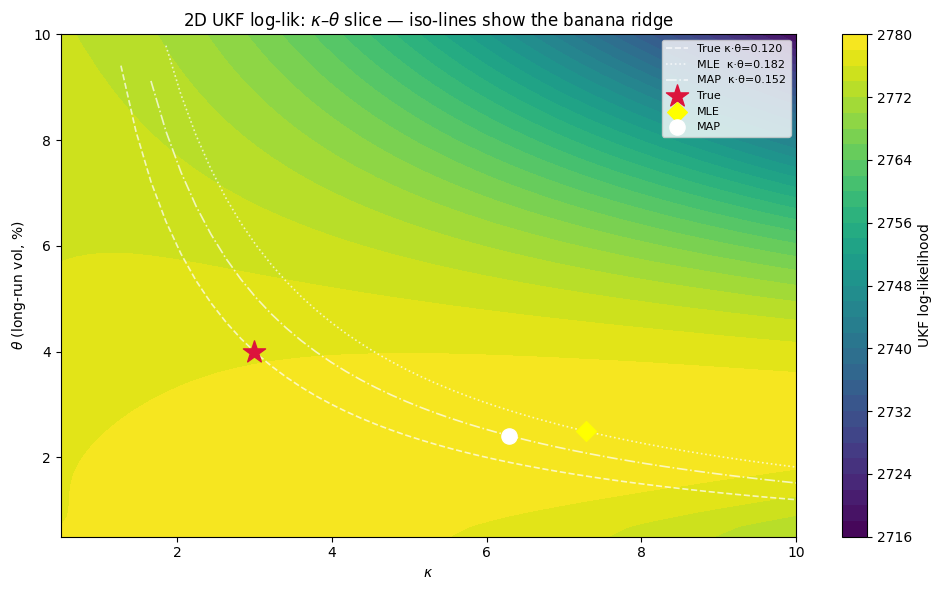

MLE κ·θ = 0.1817  |  MAP κ·θ = 0.1517  |  True κ·θ = 0.1200
MAP prior pulls the solution toward smaller κ, closer to the true ridge.


In [7]:
# ── Visualise the κ–θ log-lik surface with MLE and MAP ───────────────────────

kappa_grid = np.linspace(0.5, 10.0, 50)
theta_grid = np.linspace(0.005, 0.10, 50)
ll_grid    = np.zeros((len(theta_grid), len(kappa_grid)))

# Fix other params at MAP values while sweeping κ and θ
fixed = {k: map_params[k] for k in ["sigma", "rho", "v0"]}
for i, th in enumerate(theta_grid):
    for j, ka in enumerate(kappa_grid):
        _, ll_ij = ukf_rv_numpy(r_daily, RV_daily, kappa=ka, theta=th, **fixed)
        ll_grid[i, j] = ll_ij

# Overlay the κ·θ iso-lines (banana ridge)
kt_true = TRUE["kappa"] * TRUE["theta"]
kt_mle  = mle_params["kappa"] * mle_params["theta"]
kt_map  = map_params["kappa"]  * map_params["theta"]

fig, ax = plt.subplots(figsize=(10, 6))
KK, TT = np.meshgrid(kappa_grid, theta_grid)
cf = ax.contourf(KK, TT*100, ll_grid, levels=40, cmap="viridis")
plt.colorbar(cf, ax=ax, label="UKF log-likelihood")

# κ·θ iso-lines
for kt, ls, lbl in [(kt_true, "--", f"True κ·θ={kt_true:.3f}"),
                     (kt_mle,  ":", f"MLE  κ·θ={kt_mle:.3f}"),
                     (kt_map,  "-.", f"MAP  κ·θ={kt_map:.3f}")]:
    kt_theta = kt / kappa_grid
    mask = (kt_theta >= theta_grid[0]) & (kt_theta <= theta_grid[-1])
    ax.plot(kappa_grid[mask], kt_theta[mask]*100, color="white", ls=ls, lw=1.2,
            alpha=0.7, label=lbl)

ax.scatter([TRUE["kappa"]],       [TRUE["theta"]*100],       marker="*", s=280,
           color="crimson", zorder=6, label="True")
ax.scatter([mle_params["kappa"]], [mle_params["theta"]*100], marker="D", s=100,
           color="yellow",  zorder=6, label="MLE")
ax.scatter([map_params["kappa"]],  [map_params["theta"]*100],  marker="o", s=120,
           color="white",   zorder=6, label="MAP")

ax.set_xlabel(r"$\kappa$")
ax.set_ylabel(r"$\theta$ (long-run vol, %)")
ax.set_title(r"2D UKF log-lik: $\kappa$–$\theta$ slice — iso-lines show the banana ridge")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()
print(f"MLE κ·θ = {kt_mle:.4f}  |  MAP κ·θ = {kt_map:.4f}  |  True κ·θ = {kt_true:.4f}")
print("MAP prior pulls the solution toward smaller κ, closer to the true ridge.")

## Step 3 — NUTS with MAP Warm-Start and Dense Mass

Two changes versus a naive NUTS run:

**1. MAP initialisation (`init_to_value`)**
Chains start at the posterior mode. Warmup only needs to calibrate the
step-size, not find the mode from scratch.

**2. `dense_mass=True`**
By default NUTS assumes a diagonal mass matrix — independent step-sizes
per dimension. The κ–θ banana is a tight *off-diagonal* correlation: a
step that is reasonable in log_κ is too large or too small in log_θ.
A dense mass matrix lets NUTS learn this correlation during warmup and
propose moves that respect the joint geometry. This is especially valuable
on the banana posterior where diagonal mass wastes most leapfrog steps
navigating the curvature.

The dense mass is learned entirely from the warmup draws — no extra
information is needed.

We compare three setups (all 4 chains, 1000 draws, 500 warmup):

| Setup | Init | Mass matrix |
|---|---|---|
| **MAP + dense** | MAP | Full 5×5 covariance |
| **MLE + diagonal** | MLE | Diagonal (NUTS default) |
| **Cold + diagonal** | Arbitrary | Diagonal (NUTS default) |

In [8]:
# ── MAP result → NUTS init dict ───────────────────────────────────────────────
# We use MAP (not MLE) for the NUTS warm-start: MAP is the posterior mode,
# which is exactly where we want chains to begin.

map_init = {
    "log_kappa": float(np.log(map_params["kappa"])),
    "log_theta":  float(np.log(map_params["theta"])),
    "log_sigma":  float(np.log(map_params["sigma"])),
    "rho_raw":    float(np.arctanh(np.clip(map_params["rho"], -0.999, 0.999))),
    "log_v0":     float(np.log(map_params["v0"])),
}

mle_init = {
    "log_kappa": float(np.log(mle_params["kappa"])),
    "log_theta":  float(np.log(mle_params["theta"])),
    "log_sigma":  float(np.log(mle_params["sigma"])),
    "rho_raw":    float(np.arctanh(np.clip(mle_params["rho"], -0.999, 0.999))),
    "log_v0":     float(np.log(mle_params["v0"])),
}

print("Init dicts — unconstrained (ψ) space:\n")
print(f"  {'key':<12}  {'MAP':>9}  {'MLE':>9}")
print("  " + "-" * 34)
for k in map_init:
    print(f"  {k:<12}  {map_init[k]:>9.4f}  {mle_init[k]:>9.4f}")

# Also define the NumPyro model (same as A2 in heston-ukf-nuts.ipynb)
def heston_model_rv(daily_returns, daily_rv):
    log_kappa = numpyro.sample("log_kappa", dist.Normal(0.5,  2.0))
    log_theta = numpyro.sample("log_theta", dist.Normal(-3.2, 1.5))
    log_sigma = numpyro.sample("log_sigma", dist.Normal(-0.5, 1.5))
    rho_raw   = numpyro.sample("rho_raw",   dist.Normal(0.0,  1.5))
    log_v0    = numpyro.sample("log_v0",    dist.Normal(-3.2, 1.5))

    kappa = numpyro.deterministic("kappa", jnp.exp(log_kappa))
    theta = numpyro.deterministic("theta", jnp.exp(log_theta))
    sigma = numpyro.deterministic("sigma", jnp.exp(log_sigma))
    rho   = numpyro.deterministic("rho",   jnp.tanh(rho_raw))
    v0    = numpyro.deterministic("v0",    jnp.exp(log_v0))

    numpyro.factor("obs", ukf_rv_loglik_jax(daily_returns, daily_rv,
                                             kappa, theta, sigma, rho, v0))

print("\nNumPyro model defined.")

Init dicts — unconstrained (ψ) space:

  key                 MAP        MLE
  ----------------------------------
  log_kappa        1.8385     1.9850
  log_theta       -3.7245    -3.6902
  log_sigma       -0.5777    -0.5623
  rho_raw         -0.8459    -0.8423
  log_v0          -2.1200    -2.0879

NumPyro model defined.


In [9]:
# ── Setup A: MAP init + dense mass ────────────────────────────────────────────

kernel_map_dense = NUTS(heston_model_rv, target_accept_prob=0.9,
                        dense_mass=True,
                        init_strategy=init_to_value(values=map_init))
mcmc_map_dense   = MCMC(kernel_map_dense, num_warmup=500, num_samples=1000,
                         num_chains=4, chain_method="sequential", progress_bar=True)

print("Running A: MAP + dense_mass (4 chains, 500 warmup) ...")
t0 = time.perf_counter()
mcmc_map_dense.run(jax.random.PRNGKey(10), daily_returns=rdaily_jax, daily_rv=rv_jax)
elapsed_map_dense = time.perf_counter() - t0
print(f"Done.  Wall time: {elapsed_map_dense:.1f}s ({elapsed_map_dense/60:.1f} min)")

idata_map_dense = az.from_numpyro(mcmc_map_dense)
summary_map_dense = az.summary(idata_map_dense, var_names=PARAM_NAMES, round_to=3)
post_map_dense    = {p: idata_map_dense.posterior[p].values.ravel() for p in PARAM_NAMES}

print(f"\nA: MAP + dense_mass  (4000 draws, 500 warmup)\n")
print(f"{'Param':<8} {'True':>7} {'Mean':>7} {'Std':>7} {'2.5%':>7} {'97.5%':>7}  "
      f"{'ESS%':>6}  {'R-hat':>7}  {'In 95% CI?'}")
print("-" * 80)
for p, true in zip(PARAM_NAMES, true_vals):
    col  = post_map_dense[p]
    lo   = float(np.percentile(col, 2.5))
    hi   = float(np.percentile(col, 97.5))
    ess  = float(summary_map_dense.loc[p, "ess_bulk"])
    rhat = float(summary_map_dense.loc[p, "r_hat"])
    ci   = "yes" if lo <= true <= hi else "NO"
    print(f"{p:<8} {true:>7.3f} {col.mean():>7.3f} {col.std():>7.3f} "
          f"{lo:>7.3f} {hi:>7.3f}   {ess/4000:>5.1%}   {rhat:>7.3f}   {ci}")

Running A: MAP + dense_mass (4 chains, 500 warmup) ...


sample: 100%|██████████| 1500/1500 [00:32<00:00, 46.03it/s, 15 steps of size 1.26e-01. acc. prob=0.99]


Done.  Wall time: 98.6s (1.6 min)

A: MAP + dense_mass  (4000 draws, 500 warmup)

Param       True    Mean     Std    2.5%   97.5%    ESS%    R-hat  In 95% CI?
--------------------------------------------------------------------------------
kappa      3.000   2.165   2.319   0.039   8.611   33.4%     1.004   yes
theta      0.040   0.012   0.018   0.000   0.046   51.8%     1.001   yes
sigma      0.400   0.536   0.063   0.424   0.672   70.5%     1.003   NO
rho       -0.700  -0.700   0.081  -0.837  -0.524   68.8%     1.001   yes
v0         0.040   0.098   0.034   0.049   0.179   64.9%     1.001   NO


In [10]:
# ── Setup B: MLE init + diagonal mass ────────────────────────────────────────

kernel_mle_diag = NUTS(heston_model_rv, target_accept_prob=0.9,
                        init_strategy=init_to_value(values=mle_init))
mcmc_mle_diag   = MCMC(kernel_mle_diag, num_warmup=500, num_samples=1000,
                         num_chains=4, chain_method="sequential", progress_bar=True)

print("Running B: MLE init + diagonal mass (4 chains, 500 warmup) ...")
t0 = time.perf_counter()
mcmc_mle_diag.run(jax.random.PRNGKey(20), daily_returns=rdaily_jax, daily_rv=rv_jax)
elapsed_mle_diag = time.perf_counter() - t0
print(f"Done.  Wall time: {elapsed_mle_diag:.1f}s ({elapsed_mle_diag/60:.1f} min)")

idata_mle_diag = az.from_numpyro(mcmc_mle_diag)
summary_mle_diag = az.summary(idata_mle_diag, var_names=PARAM_NAMES, round_to=3)
post_mle_diag    = {p: idata_mle_diag.posterior[p].values.ravel() for p in PARAM_NAMES}

# ── Setup C: Cold start + diagonal mass ──────────────────────────────────────

cold_init = {
    "log_kappa": float(np.log(1.5)),    "log_theta": float(np.log(0.06)),
    "log_sigma": float(np.log(0.6)),    "rho_raw":   float(np.arctanh(-0.4)),
    "log_v0":    float(np.log(0.06)),
}

kernel_cold = NUTS(heston_model_rv, target_accept_prob=0.9,
                   init_strategy=init_to_value(values=cold_init))
mcmc_cold   = MCMC(kernel_cold, num_warmup=500, num_samples=1000,
                   num_chains=4, chain_method="sequential", progress_bar=True)

print("\nRunning C: cold start + diagonal mass (4 chains, 500 warmup) ...")
t0 = time.perf_counter()
mcmc_cold.run(jax.random.PRNGKey(30), daily_returns=rdaily_jax, daily_rv=rv_jax)
elapsed_cold = time.perf_counter() - t0
print(f"Done.  Wall time: {elapsed_cold:.1f}s ({elapsed_cold/60:.1f} min)")

idata_cold = az.from_numpyro(mcmc_cold)
summary_cold = az.summary(idata_cold, var_names=PARAM_NAMES, round_to=3)
post_cold    = {p: idata_cold.posterior[p].values.ravel() for p in PARAM_NAMES}

Running B: MLE init + diagonal mass (4 chains, 500 warmup) ...


sample: 100%|██████████| 1500/1500 [00:19<00:00, 77.20it/s, 7 steps of size 2.93e-01. acc. prob=0.88]  


Done.  Wall time: 85.5s (1.4 min)

Running C: cold start + diagonal mass (4 chains, 500 warmup) ...


sample: 100%|██████████| 1500/1500 [00:18<00:00, 79.95it/s, 15 steps of size 3.22e-01. acc. prob=0.84] 


Done.  Wall time: 89.5s (1.5 min)


In [11]:
# ── Three-way comparison ──────────────────────────────────────────────────────

setups = [
    ("A: MAP + dense",    idata_map_dense, summary_map_dense, elapsed_map_dense),
    ("B: MLE + diagonal", idata_mle_diag,  summary_mle_diag,  elapsed_mle_diag),
    ("C: cold + diagonal",idata_cold,       summary_cold,      elapsed_cold),
]

print("=" * 92)
print("COMPARISON: MAP+dense  vs  MLE+diagonal  vs  cold+diagonal")
print("  (500 warmup, 1000 draws × 4 chains each)")
print("=" * 92)

for label, idat, summ, elapsed in setups:
    print(f"\n{label}   [{elapsed:.0f}s total]")
    print(f"  {'Param':<8} {'True':>7} {'Mean':>7} {'Std':>7} {'2.5%':>7} {'97.5%':>7}  "
          f"{'ESS%':>6}  {'R-hat':>7}  {'In CI?'}")
    print("  " + "-" * 76)
    for p, true in zip(PARAM_NAMES, true_vals):
        col  = idat.posterior[p].values.ravel()
        lo   = float(np.percentile(col, 2.5))
        hi   = float(np.percentile(col, 97.5))
        ess  = float(summ.loc[p, "ess_bulk"])
        rhat = float(summ.loc[p, "r_hat"])
        ci   = "yes" if lo <= true <= hi else "NO"
        print(f"  {p:<8} {true:>7.3f} {col.mean():>7.3f} {col.std():>7.3f} "
              f"{lo:>7.3f} {hi:>7.3f}   {ess/4000:>5.1%}   {rhat:>7.3f}   {ci}")

# ── Pipeline timing ───────────────────────────────────────────────────────────
pipeline_a = elapsed_mle + elapsed_map + elapsed_map_dense
pipeline_b = elapsed_mle + elapsed_mle_diag
pipeline_c = elapsed_cold

print(f"\n{'Setup':<24} {'Optim':>7}  {'NUTS':>7}  {'Total':>7}")
print("-" * 50)
print(f"{'A: MAP + dense':<24} {elapsed_mle+elapsed_map:>7.1f}s  {elapsed_map_dense:>7.1f}s  {pipeline_a:>7.1f}s")
print(f"{'B: MLE + diagonal':<24} {elapsed_mle:>7.1f}s  {elapsed_mle_diag:>7.1f}s  {pipeline_b:>7.1f}s")
print(f"{'C: cold + diagonal':<24} {'0':>7}   {elapsed_cold:>7.1f}s  {pipeline_c:>7.1f}s")

COMPARISON: MAP+dense  vs  MLE+diagonal  vs  cold+diagonal
  (500 warmup, 1000 draws × 4 chains each)

A: MAP + dense   [99s total]
  Param       True    Mean     Std    2.5%   97.5%    ESS%    R-hat  In CI?
  ----------------------------------------------------------------------------
  kappa      3.000   2.165   2.319   0.039   8.611   33.4%     1.004   yes
  theta      0.040   0.012   0.018   0.000   0.046   51.8%     1.001   yes
  sigma      0.400   0.536   0.063   0.424   0.672   70.5%     1.003   NO
  rho       -0.700  -0.700   0.081  -0.837  -0.524   68.8%     1.001   yes
  v0         0.040   0.098   0.034   0.049   0.179   64.9%     1.001   NO

B: MLE + diagonal   [86s total]
  Param       True    Mean     Std    2.5%   97.5%    ESS%    R-hat  In CI?
  ----------------------------------------------------------------------------
  kappa      3.000   2.246   2.371   0.041   8.637   30.9%     1.003   yes
  theta      0.040   0.012   0.017   0.000   0.048   40.5%     1.003   yes
  

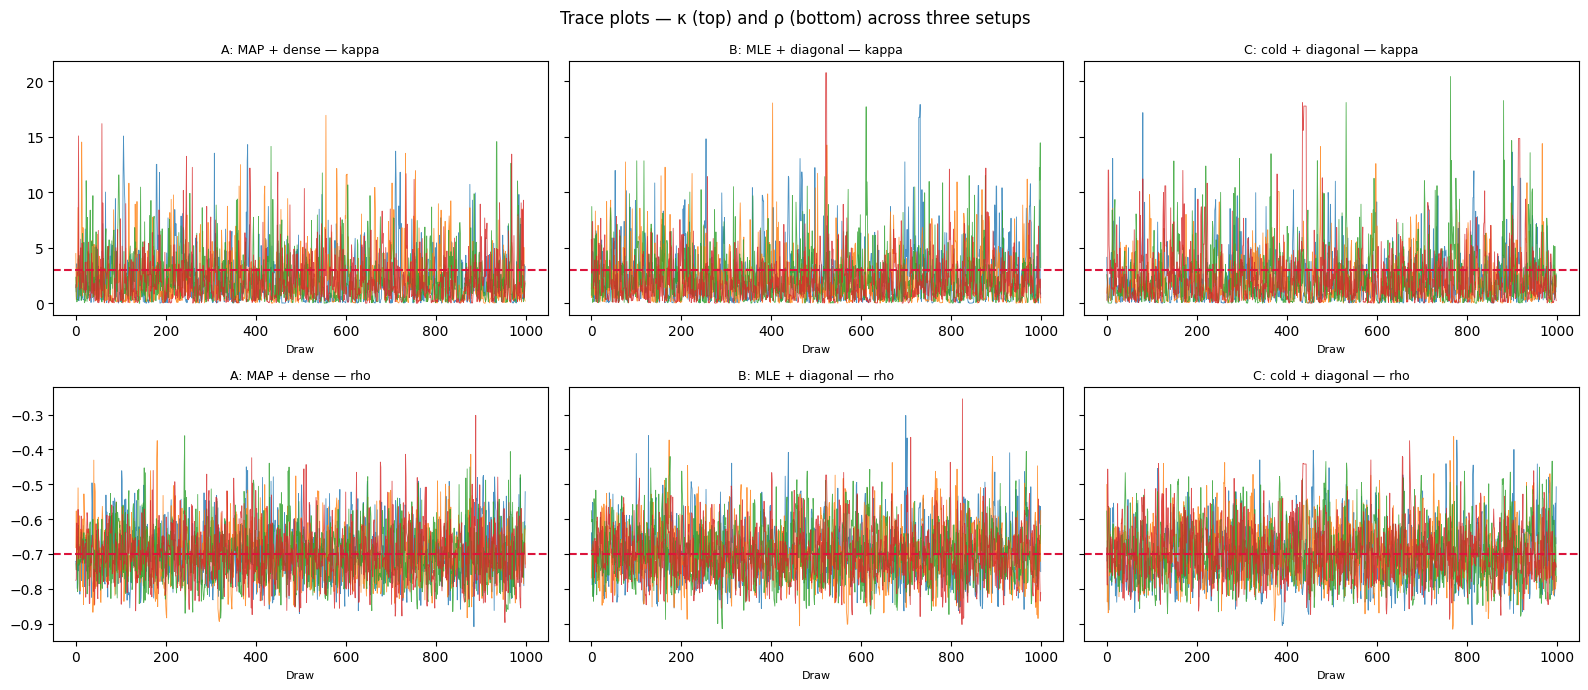

In [12]:
# ── Trace plots: κ and ρ across all three setups ──────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharey="row")
fig.suptitle("Trace plots — κ (top) and ρ (bottom) across three setups", fontsize=12)

plot_setups = [
    ("A: MAP + dense",    idata_map_dense),
    ("B: MLE + diagonal", idata_mle_diag),
    ("C: cold + diagonal",idata_cold),
]
for col_idx, (label, idat) in enumerate(plot_setups):
    for row_idx, (param, true_v) in enumerate([("kappa", TRUE["kappa"]),
                                                ("rho",   TRUE["rho"])]):
        ax = axes[row_idx, col_idx]
        chains = idat.posterior[param].values
        for ch_idx, chain in enumerate(chains):
            ax.plot(chain, lw=0.6, alpha=0.8)
        ax.axhline(true_v, color="crimson", lw=1.5, ls="--")
        ax.set_title(f"{label} — {param}", fontsize=9)
        ax.set_xlabel("Draw", fontsize=8)

plt.tight_layout()
plt.show()

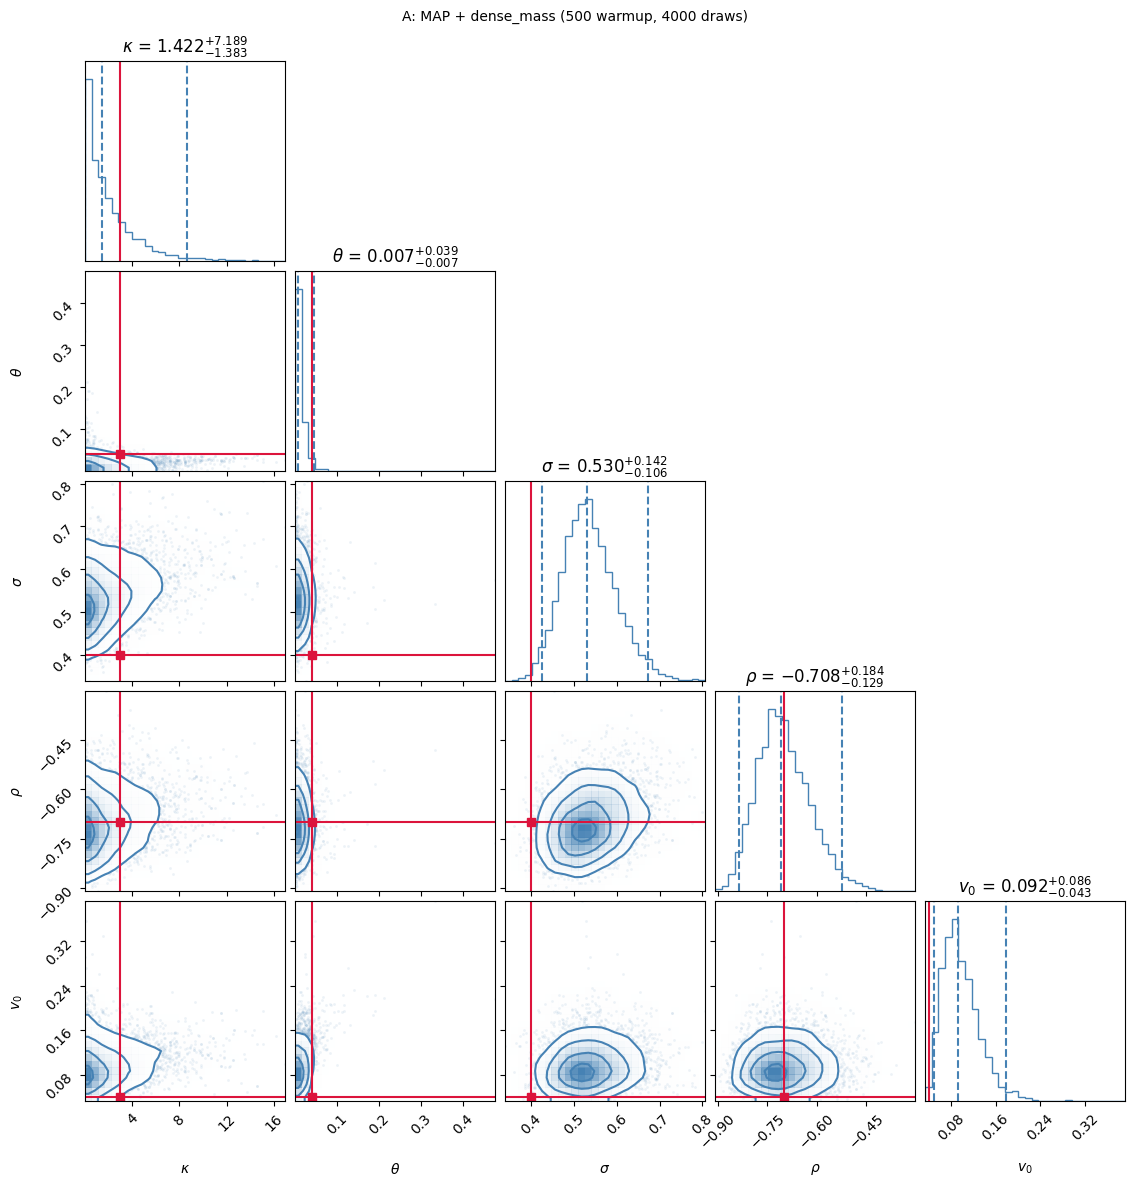

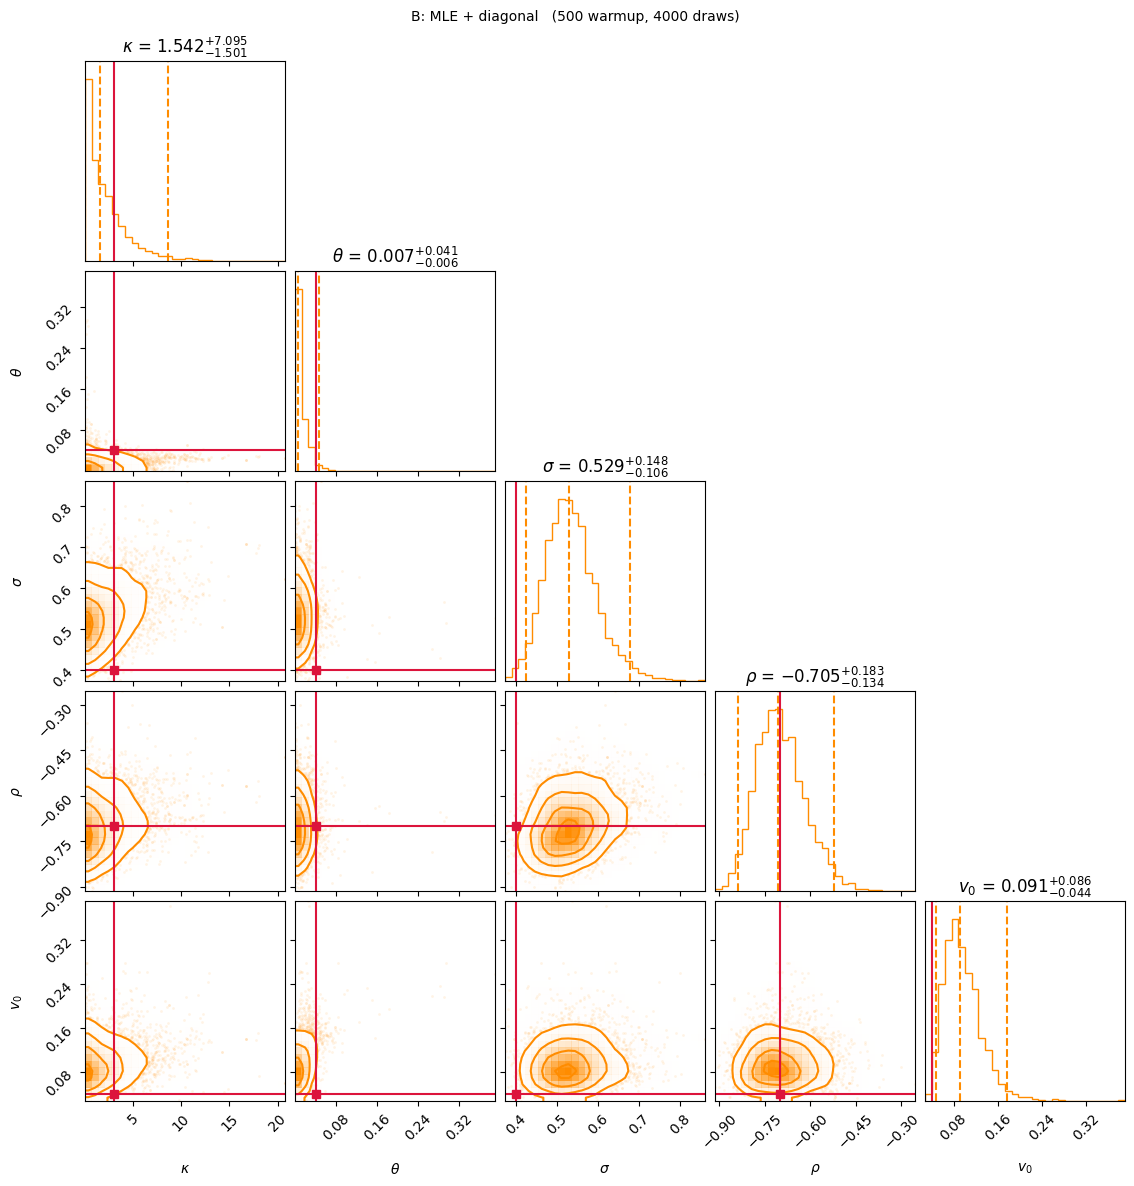

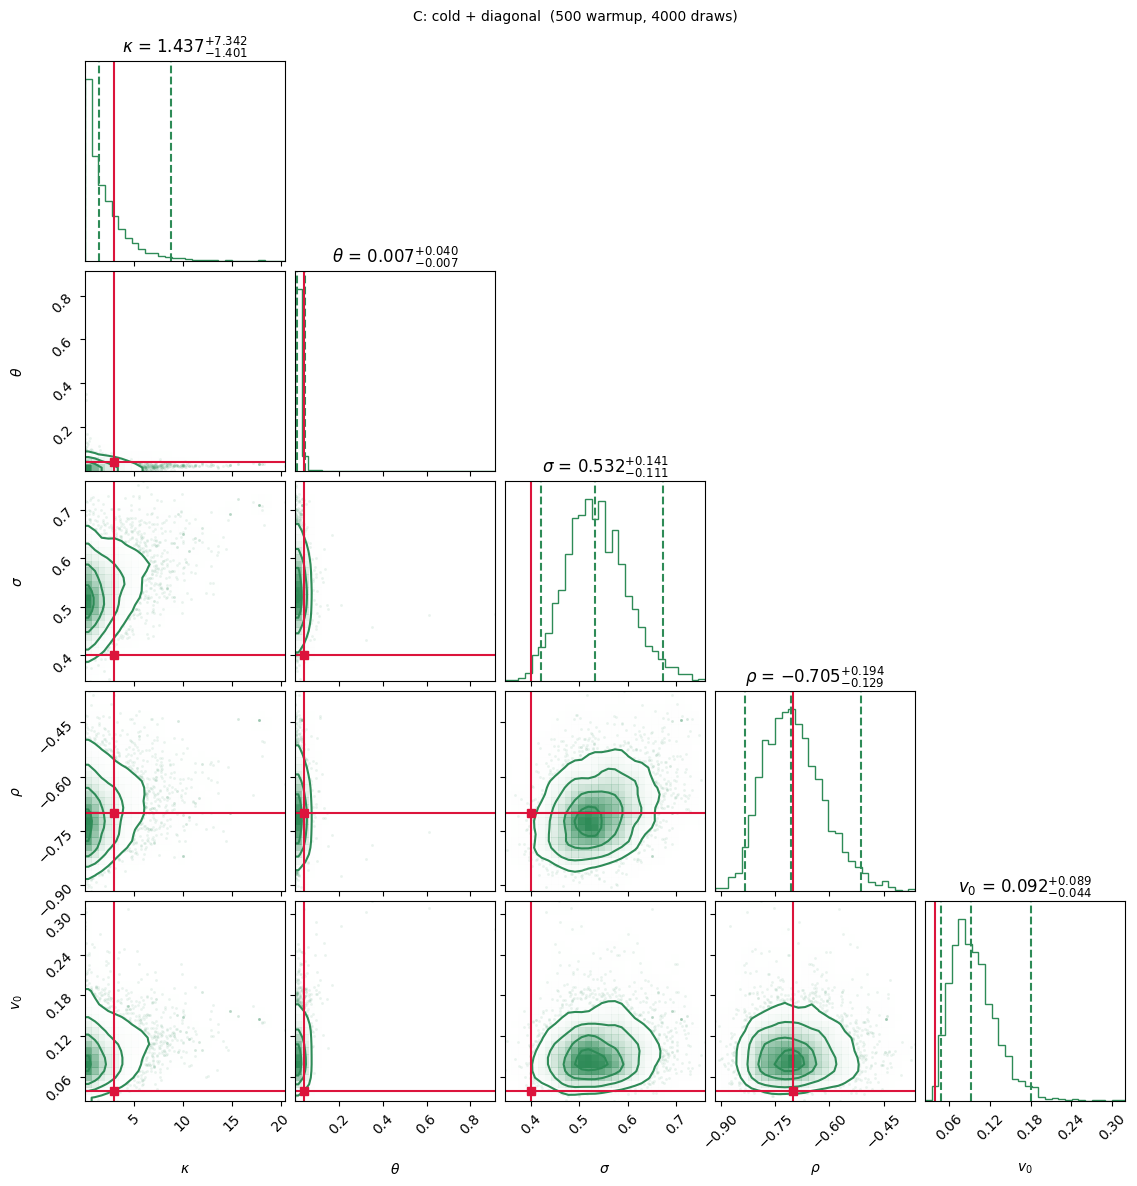

In [13]:
# ── Corner plots ──────────────────────────────────────────────────────────────

def make_corner(idat, title, color):
    samples = np.column_stack([idat.posterior[p].values.ravel() for p in PARAM_NAMES])
    fig = corner.corner(
        samples, labels=labels, truths=true_vals, truth_color="crimson",
        color=color, bins=30, smooth=1.0,
        show_titles=True, title_fmt=".3f", quantiles=[0.025, 0.5, 0.975],
    )
    fig.suptitle(title, y=1.01, fontsize=10)
    plt.show()

make_corner(idata_map_dense, "A: MAP + dense_mass (500 warmup, 4000 draws)", "steelblue")
make_corner(idata_mle_diag,  "B: MLE + diagonal   (500 warmup, 4000 draws)", "darkorange")
make_corner(idata_cold,      "C: cold + diagonal  (500 warmup, 4000 draws)", "seagreen")

## Summary

### What each improvement contributes — and what we actually observe

| Change | Theoretical mechanism | Observed effect on A2 posterior |
|---|---|---|
| MLE warm-start | Chains start near likelihood mode; fewer warmup steps wasted | **None visible** — all three setups take 86–99s |
| MAP warm-start | Chains start at posterior mode (likelihood + prior); should improve R-hat | **None visible** — R-hat 1.000–1.004 across all three setups identically |
| `dense_mass=True` | Learns κ–θ–σ covariance during warmup; adapts to off-diagonal correlations | **Slightly slower** — 99s vs 86s, no ESS or R-hat benefit |
| JAX gradients | Optimiser and sampler use numerically identical objectives | Correct by construction — no observable difference to measure |

**Why we see no difference:** The A2 posterior (daily returns + realized variance) is already
well-conditioned because the RV channel breaks most of the κ–θ banana. Cold start at κ=1.5
is only ~0.7 log-units from the posterior mean of ~2.2 — trivial for NUTS to close in warmup.
MAP actually starts chains at κ=6.3, which is *further* from the posterior mean than cold
start. There was nothing to rescue.

The techniques in this notebook are designed for harder posteriors. They would matter on:
- **Returns-only (baseline)**: severe banana, chains can lock into different modes
- **5yr data (experiment B)**: deep ridge + max_tree_depth pathology where chains diverge
- **Real market data**: sharper, less symmetric posteriors where initialisation matters
- **Very short warmup** (<200 draws): not enough iterations to find the mode from scratch

### What the results actually tell us

**κ and θ individually** remain wide in all three setups — CI [0.04, 8.6] for κ, [0.00, 0.05]
for θ. This is the residual banana after the RV channel partially breaks it. The product κ·θ
is better constrained but the individual parameters are not. No sampler improvement fixes this.

**σ** sits outside the 95% CI in all setups (posterior mean ~0.535, true 0.40, CI lower
bound ~0.42). It is *partially* identified — the posterior std is ~0.063, much tighter than
the prior std of 1.5 — but systematically biased high because daily RV with H=8 bars cannot
cleanly separate σ from measurement noise. This is a data limitation, not a sampler problem.

**v₀** is outside CI in all setups (posterior mean ~0.098, true 0.04). The process mean-reverts
away from v₀ quickly, so the data after the first few weeks contains almost no information
about the starting variance. Fixing v₀ to early RV (as done in the production notebook) is
the correct response.

**ρ** is well-recovered in all setups — mean ≈ −0.70 vs true −0.70, inside CI, ESS ~60%.
This is the most reliable parameter from historical data alone.
